<a href="https://colab.research.google.com/github/Caory2/Teoria_de_Aprendizaje_de_Maquina/blob/main/PARCIAL_TAM_2025_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Parcial 1: Teoría de Aprendizaje de Máquina - 2025-II

**Estudiantes:** Juan Manuel Mejia Vasco

Oscar David Guerrero Hernandez

Liseth Carolina Yela Medicis

**Profesor:** Andrés Marino Álvarez Meza

**Asignatura:** Teoría de Aprendizaje de Máquina
**Fecha:** 14 de Octubre de 2025
***

## Pregunta 1: Modelos de Regresión

### 1.1. Formulación del Modelo de Regresión

Se considera el modelo de regresión lineal dado por:
$$t_n = \phi(\mathbf{x}_n)\mathbf{w}^T + \eta_n$$

Donde:
* $t_n \in \mathbb{R}$ es el objetivo.
* $\mathbf{x}_n \in \mathbb{R}^P$ es el vector de características de entrada.
* $\phi: \mathbb{R}^P \to \mathbb{R}^Q$ es el vector de funciones base (o *feature map*), con $Q \geq P$.
* $\mathbf{w} \in \mathbb{R}^Q$ es el vector de pesos.
* $\eta_n \sim \mathcal{N}(0, \sigma^2)$ es el ruido o error, distribuido normalmente con media cero y varianza $\sigma^2$.

A continuación, se presenta la discusión y solución para los diferentes modelos de aprendizaje solicitados.



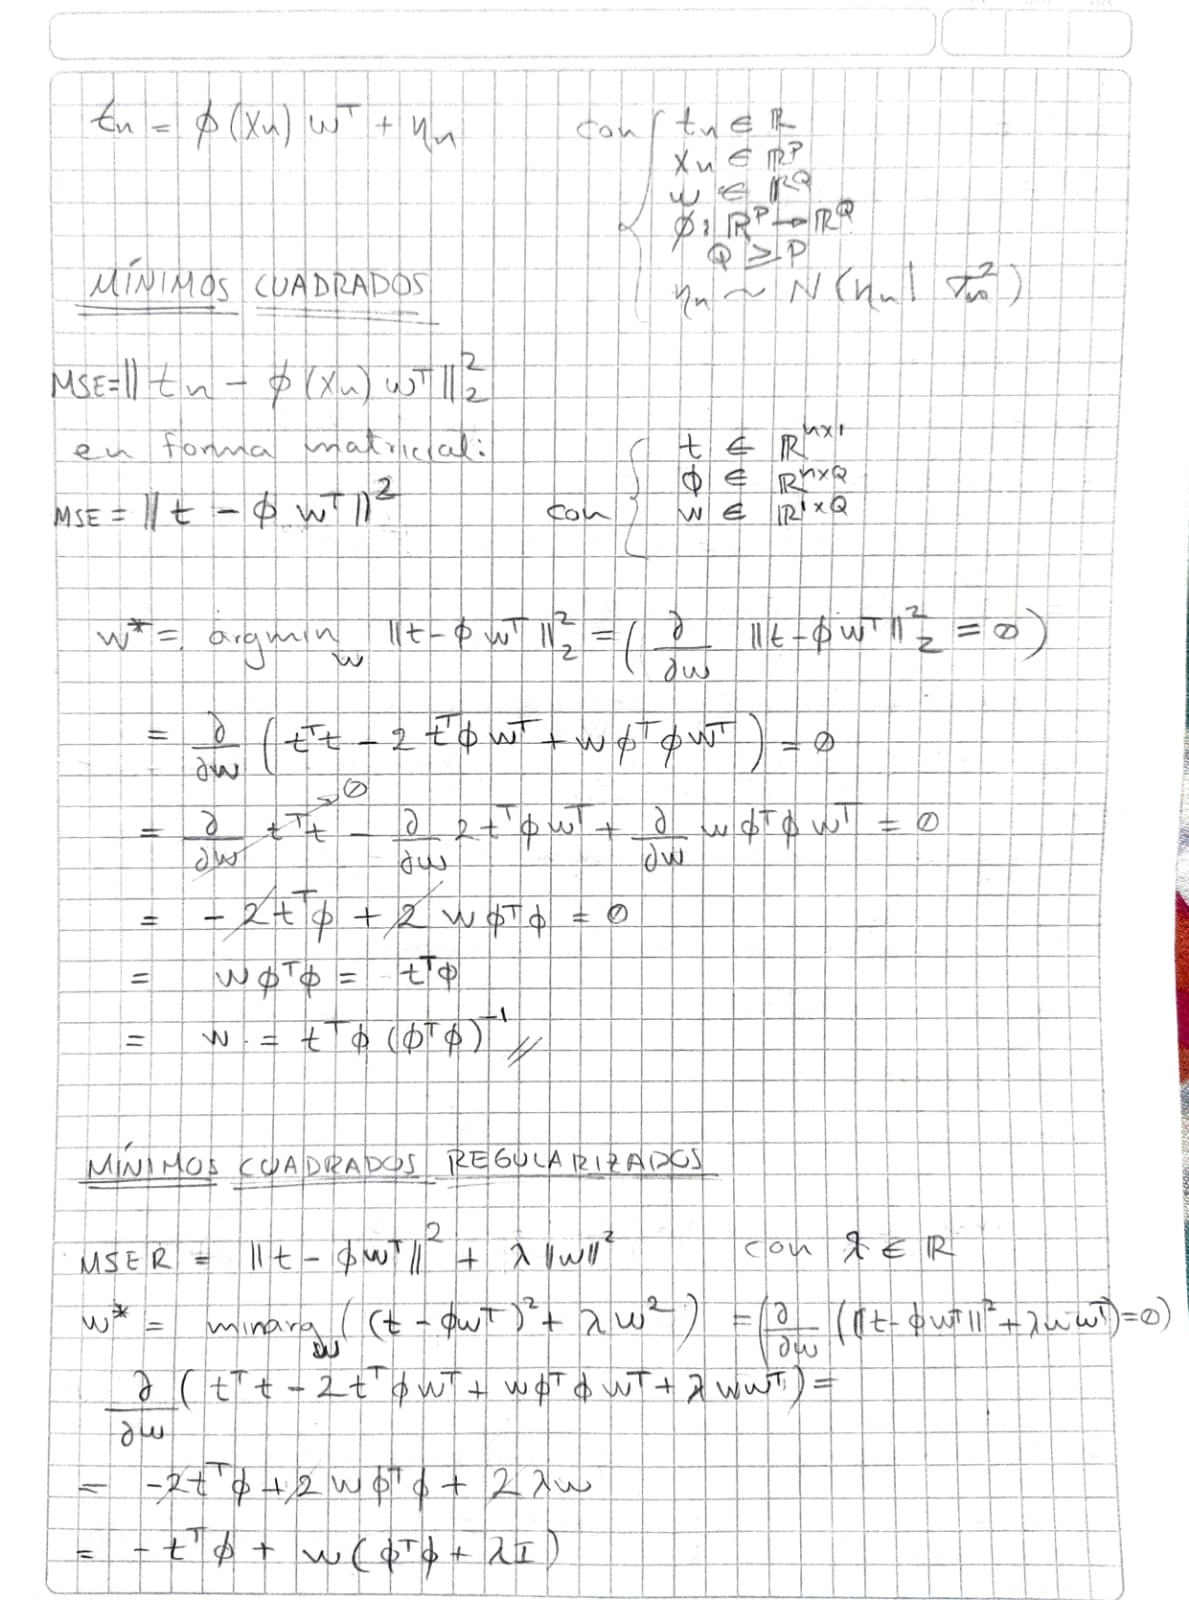

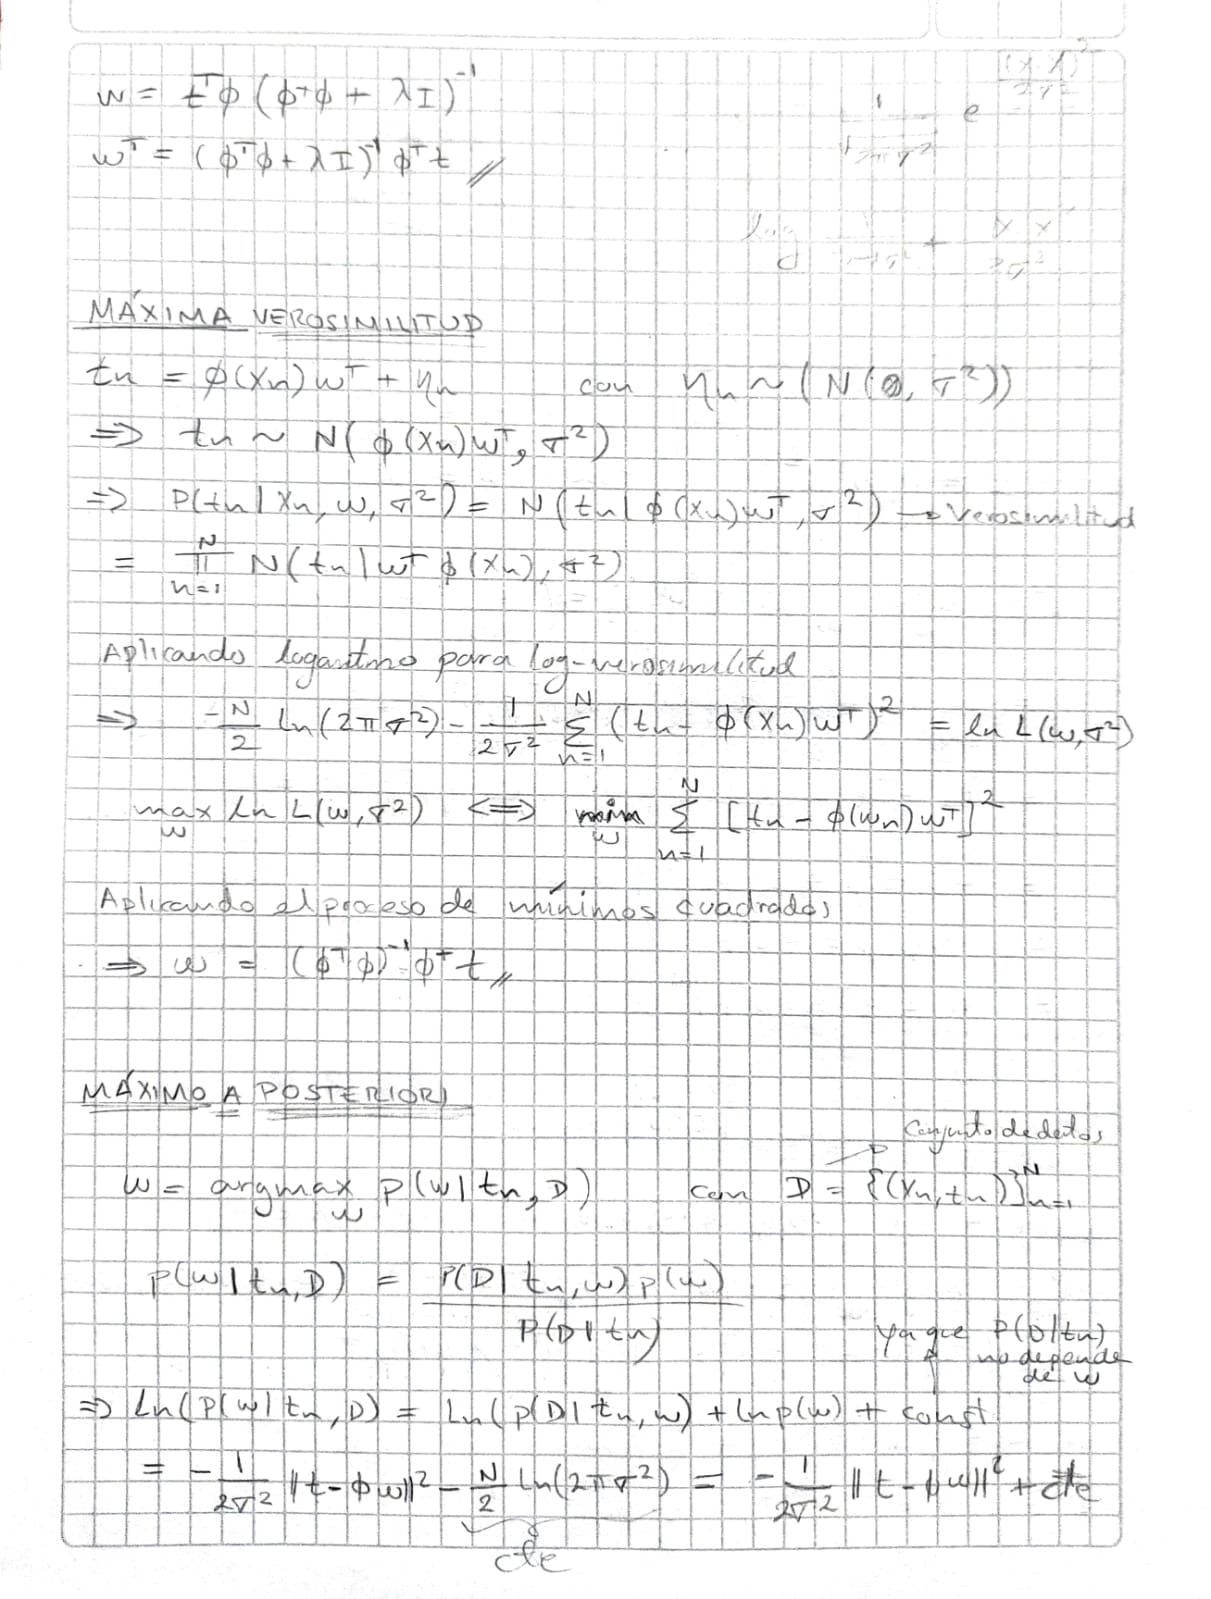

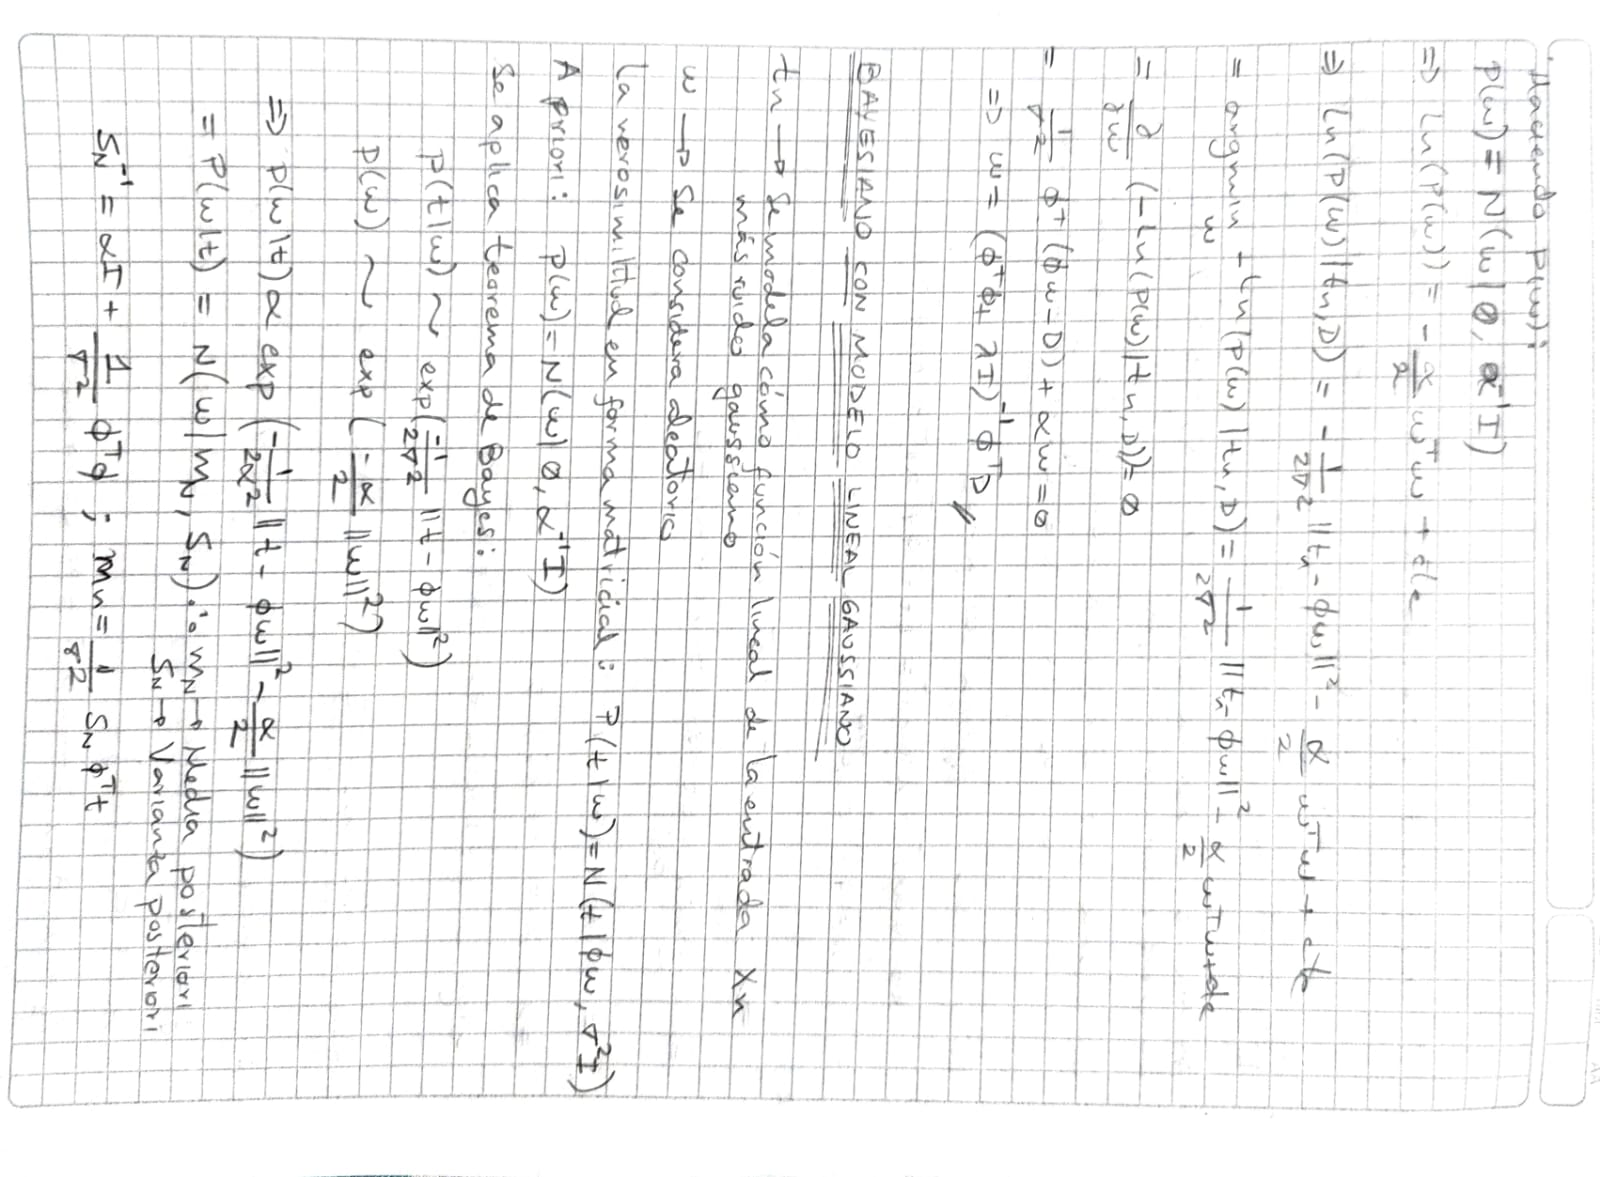

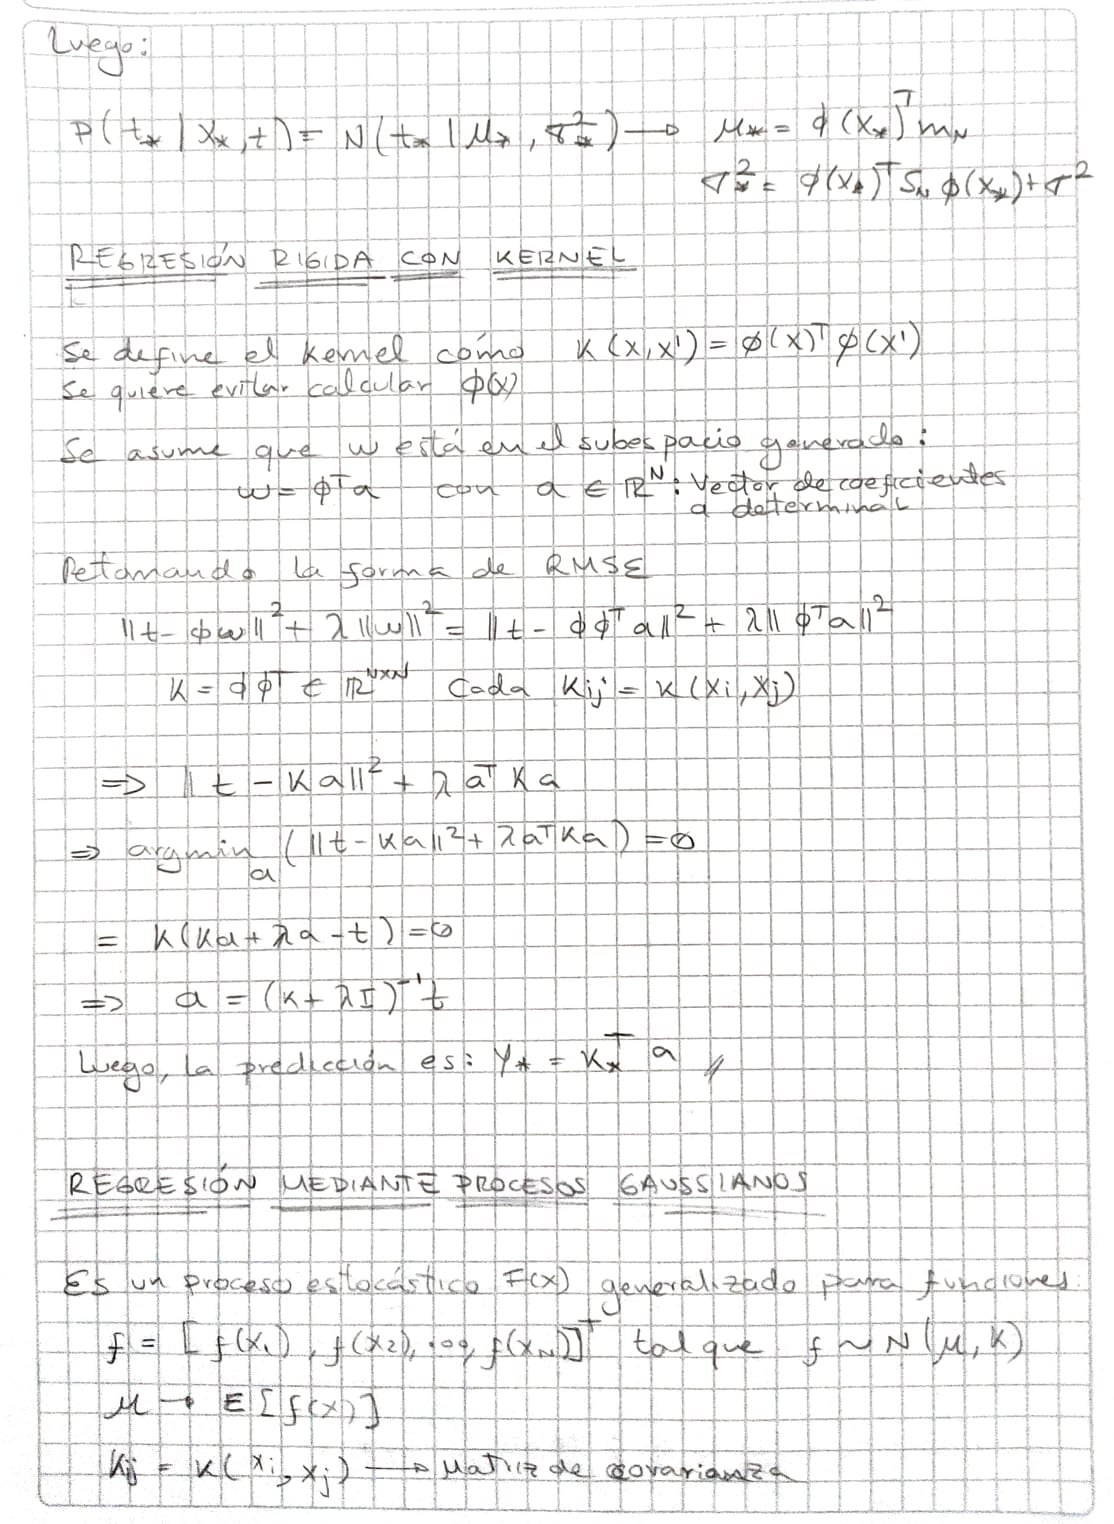

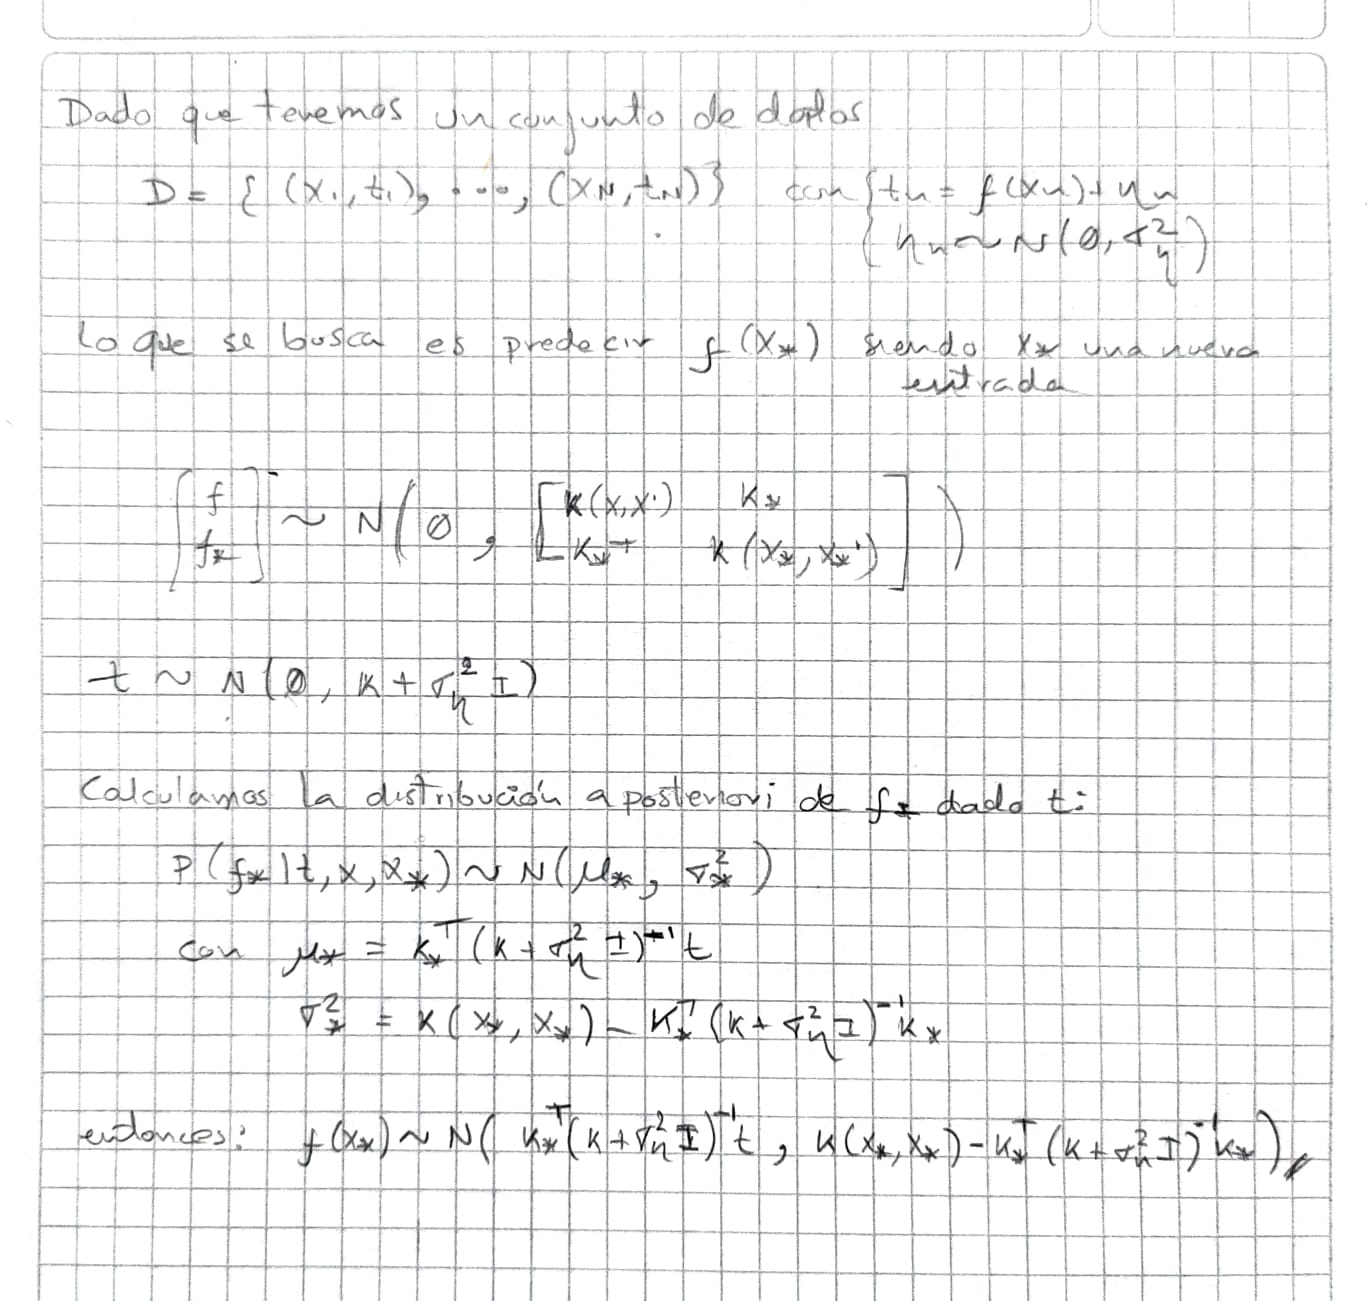

## Pregunta 2: Cuadro Comparativo de Regresores

**2.** Presente un cuadro comparativo de los siguientes regresores, en donde discuta: **modelo matemático**, **función de costo**, **estrategia de optimización**, **relación con los esquemas básicos de regresión discutidos en el punto 1**, y **escalabilidad**:
* LinearRegressor
* Lasso
* ElasticNet
* KernelRidge
* SGDRegressor
* BayesianRidge
* Gaussian Process Regressor
* Support Vector Machines Regressor
* RandomForestRegressor
* GradientBoostingRegressor y XGBoost

# Comparación detallada de modelos de regresión (Scikit-Learn)

## Pregunta 2: Cuadro Comparativo de Regresores

| Modelo / Regressor | Modelo Matemático | Función de Costo (Regularización) | Estrategia de Optimización | Relación con P. 1 / Notas | Ventajas y Desventajas / Notas Prácticas | Escalabilidad (≈ Complejidad) |
|:---|:---|:---|:---|:---|:---|:---|
| **LinearRegression** | $y = Xw + \eta$ ($\eta \sim \mathcal{N}(0, \sigma^2)$) | $J = |Xw - y|^2$ | Ecuaciones Normales, QR o SVD | Mínimos Cuadrados Ordinarios (OLS) o MLE. | ✅ Simple, interpretable. ❌ Sensible a multicolinealidad. | $O(Nd^2)$ tiempo, $O(d^2)$ memoria. Escalable hasta $10^5$ muestras. |
| **Ridge Regression** | $y = Xw + \eta$ | $J = |Xw - y|^2 + \lambda |w|_2^2$ | Solución cerrada (Tikhonov) | Variante regularizada de OLS; equivale a Prior Gaussiano en $\mathbf{w}$. | ✅ Reduce varianza; maneja multicolinealidad. ❌ No hace selección de variables. | $O(Nd^2)$. Muy estable y robusto. |
| **Lasso** | $y = Xw + \eta$ | $J = |Xw - y|^2 + \lambda |w|_1$ | Coordinate Descent / Proximal Gradient | MAP con Prior Laplaciano. Impone **esparsidad**. | ✅ Selecciona features automáticamente (sparse solution). ❌ Inestable si hay features muy correlacionadas. | Escala bien con $N$ grande usando CD/SGD. |
| **ElasticNet** | $y = Xw + \eta$ | $J = |Xw - y|^2 + \lambda_1 |w|_1 + \lambda_2 |w|_2^2$ | Coordinate Descent | Interpola entre Lasso ($L_1$) y Ridge ($L_2$). | ✅ Balancea selección y estabilidad. ❌ Requiere ajustar dos hiperparámetros. | Similar a Lasso; eficiente en datos medianos. |
| **SGDRegressor** | $y = Xw + \eta$ | $J = |Xw - y|^2 + \lambda |w|_p$ ($p=1$ o $2$) | Descenso de Gradiente Estocástico (SGD / mini-batch) | Aproxima Linear/Ridge/ElasticNet en grandes $N$. | ✅ Ideal para datasets enormes o streaming. ❌ Sensible a tasa de aprendizaje; requiere normalización. | Escalable a millones de muestras; $O(N)$ por época. |
| **KernelRidge** | $f(x) = \sum_i \alpha_i k(x_i, x)$ | $J = |y - K\alpha|^2 + \lambda \alpha^\top K \alpha$ | Solución cerrada (Cholesky / sistema lineal) | Es Ridge en el espacio de características **no lineal** ($\phi(x)$). | ✅ Captura relaciones no lineales mediante kernel. ❌ Elevado costo cúbico; no apto para $N$ grande. | $O(N^3)$ tiempo, $O(N^2)$ memoria. |
| **BayesianRidge** | $y = Xw + \eta, \quad w \sim \mathcal{N}(0, \lambda^{-1}I)$ | Maximiza evidencia marginal (log-likelihood integrada) | EM iterativo / Actualización de hiperparámetros | Regresión lineal Bayesiana; versión probabilística de Ridge. | ✅ Da intervalos de confianza e incertidumbre. ❌ Más lento; suposición de normalidad estricta. | $O(Nd^2)$ por iteración. Moderadamente escalable. |
| **GaussianProcessRegressor** | $f(x) \sim GP(0, k_\theta(x, x'))$ | Maximiza log-verosimilitud marginal | Cholesky + optimización de hiperparámetros $\theta$ (kernel) | Generaliza KernelRidge $\to$ modelo **no paramétrico**. | ✅ Gran poder predictivo y estimación de incertidumbre. ❌ Muy costoso; **no escalable**. | $O(N^3)$ tiempo, $O(N^2)$ memoria. Máx. $\sim 10k$ muestras. |
| **SVR** | $f(x) = w^\top \phi(x) + b$ | $J = \frac{1}{2}|w|^2 + C \sum_i \xi_i$ ($\varepsilon$-insensible) | Optimización cuadrática (SMO / QP) | Variante kernelizada de regresión regularizada. | ✅ Robusta a outliers, útil en relaciones no lineales. ❌ Difícil de escalar; tuning sensible ($C, \varepsilon$). | Entrenamiento $O(N^2 - N^3)$. |
| **RandomForestRegressor** | Ensamble de árboles de decisión | Minimiza error cuadrático medio por nodo | Bagging + greedy splits (árboles independientes) | No lineal; fuera del marco lineal Gaussiano. | ✅ Robusto, interpretabilidad parcial. ❌ No extrapola bien. | Escalable ($O(N \log N)$ por árbol). Paralelizable. |
| **GradientBoostingRegressor** | Ensamble secuencial de árboles débiles | Minimiza pérdida diferenciable por boosting aditivo | Boosting iterativo (gradiente funcional) | Aproxima funciones no lineales complejas. | ✅ Alta precisión; flexible. ❌ Sensible a overfitting y tuning. | Escalable a datos medianos; paralelizable parcialmente. |
| **XGBoost** | Ensamble optimizado de árboles (boosting 2º orden) | MSE con regularización $L_1/L_2$ sobre la complejidad | Boosting con optimización de segundo orden, sparsity-aware | Igual que GradientBoosting, pero más eficiente. | ✅ Extremadamente rápido; regularización avanzada y out-of-core. ❌ Más técnico. | Muy escalable ($O(N \log N)$); ideal para grandes datasets. |


## Pregunta 3: Librería RAPIDS

**3.** Consulte en qué consiste y el funcionamiento principal de la librería **RAPIDS**. Posteriormente, elabore una tabla que compare los métodos e hiperparámetros más relevantes de los regresores mencionados en el punto 2, indicando su implementación o el algoritmo equivalente disponible en RAPIDS.

### 3.1. Concepto y Funcionamiento Principal de RAPIDS

La librería **RAPIDS** (Rapid Analytics Platform for Data Science) es un ecosistema de bibliotecas **open-source** desarrollado por NVIDIA para ejecutar *pipelines* completos de Ciencia de Datos y Machine Learning **acelerados enteramente por las GPUs NVIDIA**.

Su objetivo principal es llevar tareas que en una CPU tardarían horas (debido a su naturaleza masivamente paralela, como el Álgebra Lineal o la manipulación de DataFrames) a **minutos**, aprovechando el paralelismo masivo de las unidades de procesamiento de la GPU.

#### 1. Principio de Funcionamiento

El funcionamiento de RAPIDS se basa en los siguientes pilares técnicos:

* **Ejecución en GPU con CUDA:** RAPIDS está construido sobre el *stack* de NVIDIA (CUDA) y utiliza **primitivos de GPU** (kernels paralelos, memoria de alto ancho de banda) para operar sobre los datos de forma masiva y concurrente. Esto acelera operaciones como *joins*, *groupby*, y reducciones.
* **APIs Familiares (PyData compatible):** Para facilitar la migración, las bibliotecas de RAPIDS exponen interfaces similares a las librerías estándar de Python: **cuDF** se asemeja a Pandas y **cuML** se asemeja a Scikit-learn. El usuario no necesita reescribir su código en CUDA.
* **Datos en la GPU (Evitar Transferencias):** El factor más crítico para el rendimiento es mantener los datos en la memoria de la GPU, usando estructuras como **cuDF** (formato columnar). Al **minimizar la costosa copia de datos entre CPU (host) y GPU (device)**, se logran las mayores ganancias de velocidad.
* **Optimización y Primitivas:** El ecosistema incluye gestores de memoria específicos para GPU (**RMM - RAPIDS Memory Manager**) y colecciones de utilidades y bloques de construcción de bajo nivel para ML (**RAFT**), asegurando la eficiencia y reutilización del código base.
* **Escalado Horizontal (Dask):** Para datasets que exceden la memoria de una sola GPU o para trabajos en *cluster*, RAPIDS integra **Dask** (**dask-cuDF / dask-cuML**), permitiendo distribuir la carga de trabajo entre múltiples GPUs y nodos.

#### 2. Componentes Principales (Resumen)

| Componente | Función Principal | Equivalente CPU |
|:---|:---|:---|
| **cuDF** | Manipulación de DataFrames y ETL acelerada por GPU. | Pandas |
| **cuML** | Algoritmos de Machine Learning (regresión, *clustering*, PCA, *forests*) con interfaz tipo scikit-learn. | Scikit-learn |
| **cuGraph** | Algoritmos de análisis de grafos (PageRank, *connectivity*, etc.). | NetworkX |
| **cuIO** | I/O acelerada; lectura/escritura optimizada de formatos como Parquet y CSV. | Varias librerías de I/O de Pandas. |
| **RMM** | Gestor de memoria especializado en GPU. | N/A |
| **RAFT** | Primitivas y utilidades de ML de bajo nivel. | N/A |

#### 3. Flujo de Trabajo Típico

Un flujo de trabajo estándar en RAPIDS se desarrolla **totalmente en la GPU**:

1.  **Cargar datos:** Usar `cudf.read_parquet(...)` u otros métodos de cu IO para cargar datos directamente en un **cuDF DataFrame** en la GPU.
2.  **ETL / Preprocesado:** Limpiar, filtrar, agrupar y normalizar los datos usando funciones de **cuDF** (las operaciones se ejecutan paralelamente en GPU).
3.  **Entrenamiento:** Usar **cuML** (`cuml.LinearRegression`, `cuml.RandomForestRegressor`, etc.) para entrenar el modelo.
4.  **Predicción y Evaluación:** Realizar `predict()` y calcular métricas, manteniendo los datos en la GPU.
5.  **Escalado:** Si es necesario, distribuir las operaciones usando **Dask-cuDF/cuML** para múltiples GPUs.

### 3.2. Tabla Comparativa de Implementaciones en RAPIDS (cuML)

| Modelo (sklearn) | Método Principal | Hiperparámetros Clave | Equivalente en RAPIDS | Observaciones/Notas en RAPIDS |
|:---|:---|:---|:---|:---|
| **LinearRegression** | Mínimos Cuadrados Ordinarios (MCO/OLS) | `fit_intercept`, `copy_X`, `positive` | `cuml.LinearRegression` | Implementación directa en GPU; API muy parecida. (La opción `positive=True` puede no estar disponible según la versión de cuML). |
| **Lasso** | Regresión $L_1$ (Coordinate Descent) | `alpha`, `fit_intercept`, `max_iter`, `tol` | `cuml.Lasso` | Optimización en GPU; misma lógica, distintos *solvers* internos. |
| **ElasticNet** | Mezcla $L_1$/$L_2$ | `alpha`, `l1_ratio`, `fit_intercept`, `max_iter`, `tol` | `cuml.ElasticNet` | Equivalente directo en GPU. |
| **KernelRidge** | Ridge en espacio kernel | `alpha`, `kernel`, `gamma`, `degree` | *Sin clase directa en cuML.* | Alternativas: Usar `cuml.SVR` para kernels o aproximaciones (*Nystroem*) + `cuml.Ridge`. Tarea con alta complejidad $O(N^3)$. |
| **SGDRegressor** | Descenso Estocástico (Línea Base) | `loss`, `penalty`, `alpha`, `learning_rate`, `max_iter` | `cuml.SGD` (Regresión) | Acelerado en GPU. En `cuML`, la clase se usa para clasificación y regresión. |
| **BayesianRidge** | Regresión Bayesiana Lineal | `alpha_1`, `alpha_2`, `lambda_1`, `lambda_2`, `n_iter` | *Sin clase directa en cuML.* | Usar implementación de CPU (`sklearn`) o alternativas avanzadas como Pyro/GPyTorch en GPU si la inferencia Bayesiana es esencial. |
| **GaussianProcessRegressor** | Proceso Gaussiano | `kernel`, `alpha`, `n_restarts_optimizer` | *Sin clase directa en cuML.* | Usar implementación de CPU (`sklearn`). La complejidad $O(N^3)$ limita su uso a datasets pequeños (< 10k muestras). |
| **SVR (SVM Regressor)** | SVM $\varepsilon$-Insensible | `kernel`, `C`, `epsilon`, `gamma`, `degree` | `cuml.SVR` | Acelerado en GPU. Gran ventaja para *grid searches* con kernels. |
| **RandomForestRegressor** | Ensamble de Árboles | `n_estimators`, `max_depth`, `max_features` | `cuml.RandomForestRegressor` | Entrenamiento e inferencia en GPU. La librería **FIL** (*Forest Inference Library*) acelera el *serving*. |
| **GradientBoostingRegressor** | Boosting de Árboles | `n_estimators`, `learning_rate`, `max_depth`, `subsample` | `cuml.experimental.GradientBoostingRegressor` (o **XGBoost**) | En la práctica, **XGBoost con `gpu_hist`** es la opción más madura y con mejor rendimiento en GPU para boosting. |
| **XGBRegressor (XGBoost)** | Boosting de Árboles (Hist) | **`tree_method="gpu_hist"`**, `max_depth`, `learning_rate` | `xgboost.XGBRegressor` | Integración natural con RAPIDS: puede consumir datos directamente desde cuDF. Ofrece el mejor rendimiento en GPU. |


## Pregunta 4: Análisis, Modelado y Evaluación

**4.** Presente un **análisis detallado** del conjunto de datos disponible en [https://www.kaggle.com/competitions/nfl-big-data-bowl-2026-prediction/overview](https://www.kaggle.com/competitions/nfl-big-data-bowl-2026-prediction/overview). Incluya la **descripción de las variables de entrada y salida**, el **objetivo principal** del concurso, un **análisis exploratorio básico**, los procedimientos de **codificación de valores faltantes y variables categóricas**, así como las estrategias de **ingeniería de características** —si aplican—. Finalmente, proporcione todos los detalles necesarios para comprender, interpretar y analizar adecuadamente el conjunto de datos.

Luego, utilizando un **esquema de validación hold-out** con una partición del **60% para entrenamiento**, **20% para validación** y **20% para evaluación** del rendimiento, compare los regresores mencionados en el punto 2—considerando sus posibles implementaciones en **RAPIDS**, según lo indicado en el punto 3—, empleando el conjunto de datos de entrenamiento disponible en el *dataset*.

Realice las consideraciones necesarias para la implementación y **sintonización de cada modelo mediante optimización bayesiana**, con el fin de determinar los hiperparámetros más relevantes de cada algoritmo. Justifique la selección de los hiperparámetros a optimizar, así como la rejilla o los rangos de valores definidos para cada modelo, de acuerdo con las características estudiadas y el *score* a minimizar.

Finalmente, presente los **rendimientos promedios** obtenidos sobre el conjunto de **evaluación**, junto con su respectiva **desviación estándar**, empleando las siguientes **métricas de desempeño**: MAE, MSE, R2 (*consultar*) y MAPE (*consultar*).



### Coeficiente de Determinación ($R^2$)

El coeficiente de determinación ($R^2$) es una métrica clave para evaluar modelos de regresión, ya que mide la proporción de la variabilidad total de la variable dependiente que es explicada por el modelo.

#### 1. Definición Matemática

$$R^2 = 1 - \frac{\sum_{i=1}^n (y_i - \hat{y}_i)^2}{\sum_{i=1}^n (y_i - \bar{y})^2}$$

**Donde:**
* $y_i$: valor real de la variable de salida (observación $i$).
* $\hat{y}_i$: valor predicho por el modelo (observación $i$).
* $\bar{y}$: media de los valores reales.
* $n$: número de observaciones.

#### 2. Interpretación

* El $R^2$ es una métrica **adimensional** (no depende de las unidades de la variable de salida).
* Su rango típico es de 0 a 1, pero puede ser negativo:
    * **$R^2 = 1$:** El modelo predice perfectamente todos los valores (ajuste perfecto).
    * **$R^2 = 0$:** El modelo no explica mejor la variabilidad de la variable de salida que simplemente usando la media ($\bar{y}$) como predicción.
    * **$R^2 < 0$:** El modelo es peor que usar la media como predicción.


#### 3. Intuición y Ejemplo

La intuición del $R^2$ es que mide **qué tan bien el modelo "captura la tendencia general" del fenómeno**. En contextos de regresión múltiple, un $R^2$ alto significa que la combinación de las variables de entrada logra predecir razonablemente bien la variable de salida.

**Ejemplo práctico (NFL Big Data Bowl):**
Supongamos que el objetivo es predecir la posición final $X$ de un jugador. Si un modelo tiene **$R^2 = 0.85$**, significa que el **85% de la variabilidad en la posición real** se explica por las características de entrada (velocidad, ángulo, dirección, aceleración, etc.) que se están utilizando.

***

### MAPE — Mean Absolute Percentage Error

El Error Porcentual Absoluto Medio (MAPE) es una métrica de error útil porque proporciona una **interpretación directa en términos de porcentaje**.

#### 1. Definición Matemática

$$MAPE = \frac{100\%}{n}\sum_{i=1}^n \left| \frac{y_i - \hat{y}_i}{y_i} \right|$$

**Donde:**
* $y_i$: valor real.
* $\hat{y}_i$: predicción del modelo.
* $n$: número de observaciones.
* El resultado se multiplica por 100 para expresarlo como porcentaje.

#### 2. Interpretación
El MAPE representa el **error promedio, expresado como un porcentaje del valor real**. Por ejemplo, un MAPE de **$15\%$** significa que el modelo está errando en promedio en un 15% del valor real. Es importante notar que el MAPE puede ser sensible y dar resultados extremos o infinitos si los valores reales ($y_i$) son muy cercanos o iguales a cero.

### MAPE — Mean Absolute Percentage Error (Continuación)

#### 3. Interpretación e Intuición

El MAPE mide el **error relativo promedio** entre las predicciones ($\hat{y}_i$) y los valores reales ($y_i$). En otras palabras, indica **en promedio cuánto porcentaje se equivoca el modelo respecto al valor verdadero**.

* **Intuición:**
    * **MAPE = 5%** $\to$ Las predicciones difieren en promedio un 5% de los valores reales.
    * **MAPE = 20%** $\to$ El error promedio relativo es del 20%.
    * Mientras **más bajo**, mejor.

#### 4. Limitaciones

El MAPE presenta dos limitaciones críticas que deben ser consideradas:

1.  **Indefinición:** Si algún valor real ($y_i$) es igual a **cero**, el MAPE **no está definido** (división por cero).
2.  **Penalización Asimétrica:** Tiende a **penalizar más los errores sobre valores pequeños** de la variable real ($y_i$), lo cual puede sesgar la optimización hacia valores grandes.

**DESARROLLO ENTRENAMIENTO NFL**
[texto del enlace](https://www.kaggle.com/code/oscarguerrer07/nfl-big-data-bowl-2026-analysis-prediction-b2abe6)